# It is working, but not good with my TPM data

In [2]:
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from cobra.io import read_sbml_model

In [4]:
df = pd.read_csv('/scratch/rebernig/VR002_Model_Analysis/Data/Transcriptomics_Data_Juan/Buniformis/Buniformis_All.csv', index_col=0)  

model = read_sbml_model("/scratch/rebernig/VR002_Model_Analysis/Output/Curated_Models_Elena/B.Uniformis/Confidence_Levels_Biomass/curated.xml")

# Get all gene objects
genes = model.genes

# Get gene IDs as a list
gene_ids = [gene.id for gene in genes]

model_gene_set = set(gene_ids)

gene_names = df.index.tolist()


expression_gene_set = set(gene_names)

Overlapping_genes = model_gene_set & expression_gene_set


filtered_df = df.loc[df.index.intersection(Overlapping_genes)]
filtered_df = filtered_df.rename(columns={"Name": "gene"})
filtered_df

,sample1,sample5,sample9,sample13,sample16,sample19,sample45,sample46,sample85,sample15,sample18,sample21
Name,,,,,,,,,,,,
BU_ATCC8492_00003,13.221902,5.122181,1.395724,19.726952,10.513327,9.458930,395.686110,369.476769,452.150803,1.401671,1.926033,3.009692
BU_ATCC8492_00004,171.930400,139.329942,147.433482,243.691016,261.677876,106.238174,3327.268227,3196.768989,3588.120968,252.456538,595.338608,145.618614
BU_ATCC8492_00067,35.551832,15.508464,15.122730,25.649080,0.000000,27.671731,15.679178,36.256265,0.000000,44.180829,50.752556,23.851983
BU_ATCC8492_00068,462.718219,492.852808,142.052261,652.366316,660.129968,351.255039,66.341955,196.021348,174.560197,364.530146,330.594152,513.024443
BU_ATCC8492_00070,16.994192,13.834217,8.363878,26.424252,20.160356,23.339910,195.536770,179.387942,76.259884,25.872293,16.837383,12.730996
...,...,...,...,...,...,...,...,...,...,...,...,...
BU_ATCC8492_03876,35.849054,24.898066,7.859452,1.882784,3.532022,2.482649,153.074814,133.070527,59.466191,102.936547,109.412598,18.712397
BU_ATCC8492_03881,73.572229,27.575291,34.232030,49.011375,73.940354,19.960443,497.420346,659.492724,245.317941,112.671760,92.268598,54.232728
BU_ATCC8492_03882,556.880812,546.973420,502.693109,756.337315,790.912391,645.641557,1168.016729,1021.516202,927.429624,523.053466,568.106409,730.747748


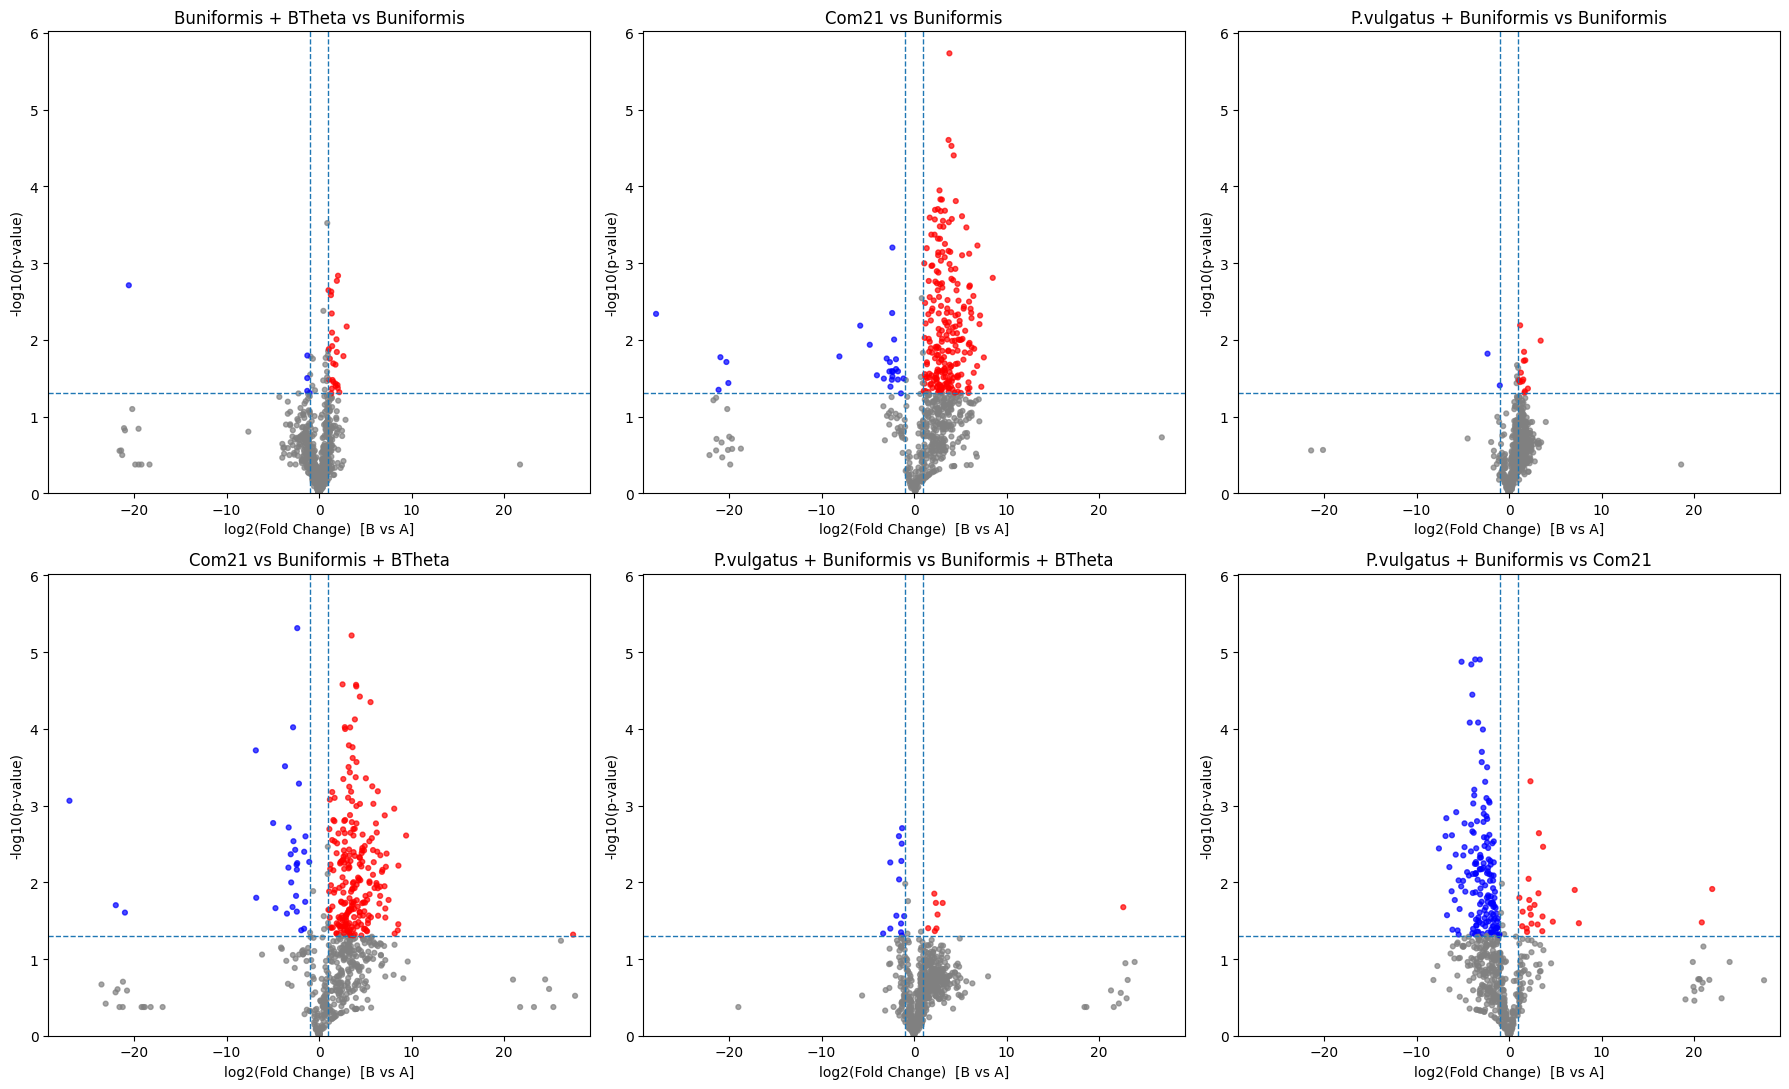

In [5]:




sample_to_condition = {
    'sample1': 'Buniformis',
    'sample5': 'Buniformis',
    'sample9': 'Buniformis',
    'sample13': 'Buniformis + BTheta',
    'sample16': 'Buniformis + BTheta',
    'sample19': 'Buniformis + BTheta',
    'sample45': 'Com21',
    'sample46': 'Com21',
    'sample85': 'Com21',
    'sample15': 'P.vulgatus + Buniformis',
    'sample18': 'P.vulgatus + Buniformis',
    'sample21': 'P.vulgatus + Buniformis'
}

# thresholds
fc_thresh   = 1.0       # |log2FC| highlight threshold
pval_thresh = 0.05      # p-value threshold (uncorrected here)
eps = 1e-6              # to avoid log(0)

# ------------------------
# LOAD + PREP
# ------------------------
# Read your wide table (genes as index, samples as columns)
df_new = pd.read_csv(
    '/scratch/rebernig/VR002_Model_Analysis/Data/Transcriptomics_Data_Juan/Buniformis/Buniformis_All.csv',
    index_col=0
)

# Optional: keep only overlapping genes if you have that list/Index defined
if 'Overlapping_genes' in globals() or 'Overlapping_genes' in locals():
    df_new = df_new.loc[df_new.index.intersection(Overlapping_genes)]

# Keep only sample columns that appear in the mapping
available_samples = [c for c in df_new.columns if c in sample_to_condition]
if not available_samples:
    raise ValueError("No DataFrame columns match keys in sample_to_condition.")

# Reset index to get a gene column named 'gene'
df_wide = df_new[available_samples].copy()
df_wide = df_wide.reset_index()
# Standardize the gene column name
if 'Name' in df_wide.columns:
    df_wide = df_wide.rename(columns={'Name': 'gene'})
elif 'index' in df_wide.columns:
    df_wide = df_wide.rename(columns={'index': 'gene'})
elif df_wide.columns[0] != 'gene':
    # ensure first column is called gene
    df_wide = df_wide.rename(columns={df_wide.columns[0]: 'gene'})

# Long format
df_long = df_wide.melt(id_vars='gene', var_name='sample', value_name='expression')

# Map sample -> condition and drop samples not in mapping
df_long['condition'] = df_long['sample'].map(sample_to_condition)
df_long = df_long.dropna(subset=['condition'])

# Unique conditions present in the data
conditions = sorted(df_long['condition'].unique())
if len(conditions) < 2:
    raise ValueError("Need at least 2 conditions present to compare.")

# ------------------------
# STATS PER PAIR
# ------------------------
pair_results = {}   # (condA, condB) -> DataFrame with gene, log2FC, pvalue, neg_log10_p
global_max_abs_fc = 0.0
global_max_neglogp = 0.0

for cond_a, cond_b in itertools.combinations(conditions, 2):
    rows = []
    for gene, grp in df_long.groupby('gene', sort=False):
        expr_a = grp.loc[grp['condition'] == cond_a, 'expression'].dropna()
        expr_b = grp.loc[grp['condition'] == cond_b, 'expression'].dropna()
        if len(expr_a) == 0 or len(expr_b) == 0:
            continue

        # Welch's t-test: B vs A
        _, pval = ttest_ind(expr_b, expr_a, equal_var=False)
        mean_a = expr_a.mean()
        mean_b = expr_b.mean()
        log2fc = np.log2((mean_b + eps) / (mean_a + eps))

        rows.append((gene, log2fc, pval))

    res = pd.DataFrame(rows, columns=['gene', 'log2FC', 'pvalue'])
    if res.empty:
        # keep placeholder to avoid breaking the grid
        res['neg_log10_pval'] = []
        pair_results[(cond_a, cond_b)] = res
        continue

    res['neg_log10_pval'] = -np.log10(res['pvalue'].clip(lower=np.finfo(float).tiny))

    # track global axes limits for a consistent facet grid
    global_max_abs_fc = max(global_max_abs_fc, float(np.abs(res['log2FC']).max()))
    global_max_neglogp = max(global_max_neglogp, float(res['neg_log10_pval'].max()))
    pair_results[(cond_a, cond_b)] = res

# Pad the axes a bit
global_max_abs_fc = max(global_max_abs_fc, fc_thresh) * 1.05
global_max_neglogp = max(global_max_neglogp, -np.log10(pval_thresh)) * 1.05

# ------------------------
# FACET GRID PLOTTING
# ------------------------
n_pairs = len(pair_results)
ncols = min(3, n_pairs)                 # up to 3 columns; tweak if you prefer 2
nrows = math.ceil(n_pairs / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5.5*nrows), squeeze=False)

for ax, ((cond_a, cond_b), res) in zip(axes.flat, pair_results.items()):
    if res.empty:
        ax.set_axis_off()
        ax.set_title(f"{cond_b} vs {cond_a} (no data)")
        continue

    # Colors per point
    highlight = (res['pvalue'] < pval_thresh) & (res['log2FC'].abs() >= fc_thresh)
    colors = np.where(highlight,
                      np.where(res['log2FC'] > 0, 'red', 'blue'),
                      'grey')

    ax.scatter(res['log2FC'], res['neg_log10_pval'], c=colors, alpha=0.7, s=12)

    # threshold lines
    ax.axvline(fc_thresh, linestyle='--', linewidth=1)
    ax.axvline(-fc_thresh, linestyle='--', linewidth=1)
    ax.axhline(-np.log10(pval_thresh), linestyle='--', linewidth=1)

    ax.set_xlim(-global_max_abs_fc, global_max_abs_fc)
    ax.set_ylim(0, global_max_neglogp)
    ax.set_xlabel('log2(Fold Change)  [B vs A]')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'{cond_b} vs {cond_a}')

# If there are unused subplots, hide them
for i in range(n_pairs, nrows*ncols):
    axes.flat[i].set_axis_off()

plt.tight_layout()
plt.show()